<a href="https://colab.research.google.com/github/Santhoshbabu009/192324146-ITA0604-MACHINE-LEARNING/blob/main/IDE_ASSIGNMENT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


First Five Records

  pH_Band Turbidity TDS_Band Residual_Chlorine Microbial       Source  \
0    High      High      Low               Low   Present         Lake   
1     Low      High     High            Normal    Absent  Groundwater   
2    High      High   Medium               Low   Present         Lake   
3    High       Low      Low               Low    Absent  Groundwater   
4     Low       Low      Low               Low   Present        River   

             Class  
0  Needs Treatment  
1  Needs Treatment  
2  Needs Treatment  
3  Needs Treatment  
4  Needs Treatment  

Dataset Shape : (100, 7)

Class Distribution

Class
Needs Treatment    82
Safe               18
Name: count, dtype: int64

Encoded Dataset

   pH_Band  Turbidity  TDS_Band  Residual_Chlorine  Microbial  Source  Class
0        0          0         1                  0          1       1      0
1        1          0         0                  1          0       0      0
2        0          0         2           

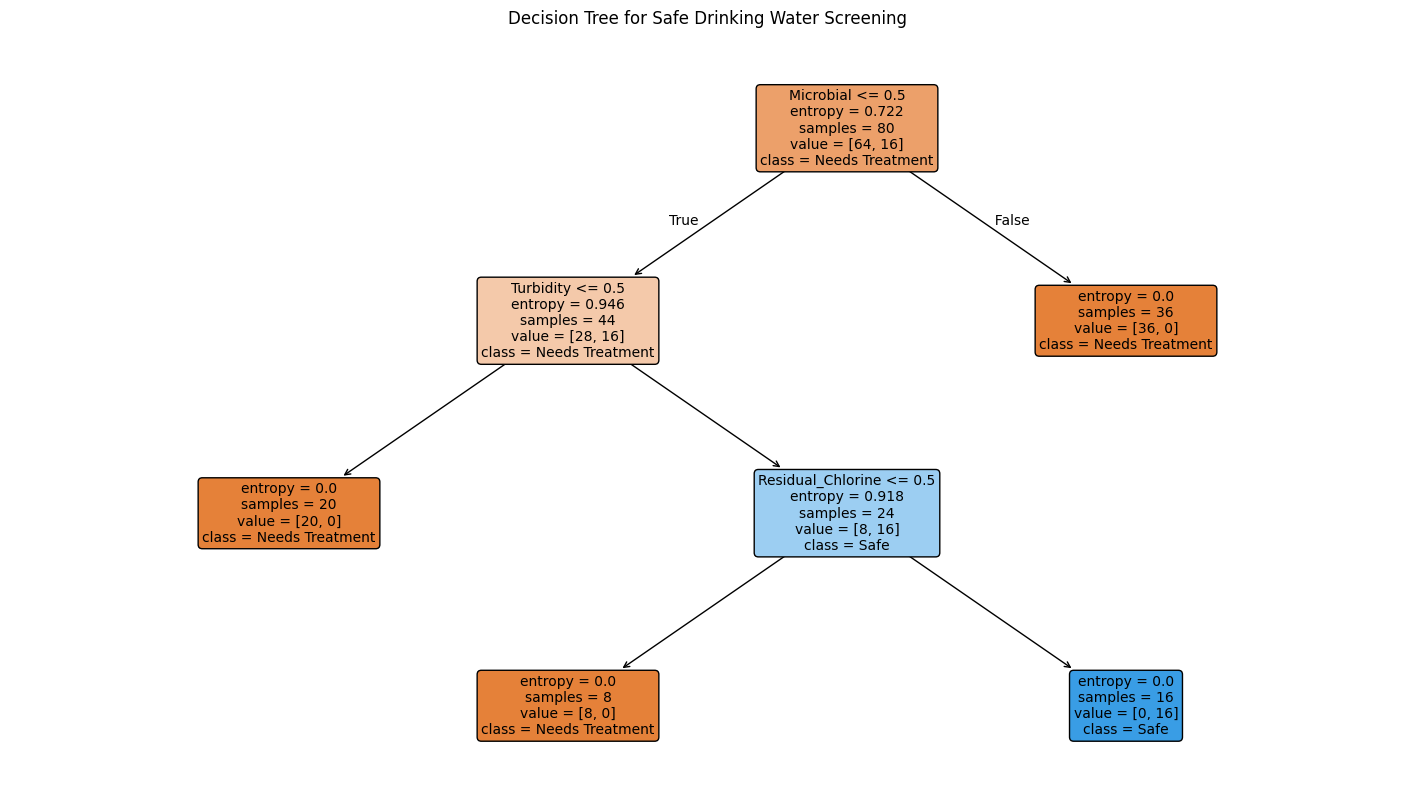


--------------------------------------------
MODEL SUMMARY
--------------------------------------------
Algorithm           : Decision Tree
Criterion           : Entropy
Training Records    : 80
Testing Records     : 20
Total Records       : 100
Accuracy            : 100.0 %

This model is intended only for educational
water quality screening and should not
replace certified laboratory testing.


In [1]:
# ==========================================================
# Safe Drinking Water Quality Screening using Decision Tree
# ==========================================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# ----------------------------------------------------------
# Step 1 : Generate Synthetic Dataset
# ----------------------------------------------------------

np.random.seed(42)

n = 100

df = pd.DataFrame({
    "pH_Band": np.random.choice(["Low", "Normal", "High"], n),
    "Turbidity": np.random.choice(["Low", "High"], n),
    "TDS_Band": np.random.choice(["Low", "Medium", "High"], n),
    "Residual_Chlorine": np.random.choice(["Low", "Normal"], n),
    "Microbial": np.random.choice(["Present", "Absent"], n),
    "Source": np.random.choice(["River", "Lake", "Groundwater"], n)
})

# ----------------------------------------------------------
# Step 2 : Create Target Class
# ----------------------------------------------------------

def classify(row):

    if (row["Microbial"] == "Absent" and
        row["Turbidity"] == "Low" and
        row["Residual_Chlorine"] == "Normal"):

        return "Safe"

    else:
        return "Needs Treatment"

df["Class"] = df.apply(classify, axis=1)

# ----------------------------------------------------------
# Step 3 : Display Dataset
# ----------------------------------------------------------

print("\nFirst Five Records\n")
print(df.head())

print("\nDataset Shape :", df.shape)

print("\nClass Distribution\n")
print(df["Class"].value_counts())

# ----------------------------------------------------------
# Step 4 : Data Preprocessing
# ----------------------------------------------------------

encoder = LabelEncoder()

for column in df.columns:
    df[column] = encoder.fit_transform(df[column])

print("\nEncoded Dataset\n")
print(df.head())

# ----------------------------------------------------------
# Step 5 : Feature Selection
# ----------------------------------------------------------

X = df.drop("Class", axis=1)
y = df["Class"]

# ----------------------------------------------------------
# Step 6 : Train-Test Split
# ----------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

# ----------------------------------------------------------
# Step 7 : Train Decision Tree
# ----------------------------------------------------------

model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    random_state=42
)

model.fit(X_train, y_train)

print("\nModel Training Completed Successfully")

# ----------------------------------------------------------
# Step 8 : Prediction
# ----------------------------------------------------------

y_pred = model.predict(X_test)

# ----------------------------------------------------------
# Step 9 : Evaluation
# ----------------------------------------------------------

print("\nConfusion Matrix\n")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", round(accuracy * 100, 2), "%")
print("Precision:", round(precision * 100, 2), "%")
print("Recall   :", round(recall * 100, 2), "%")
print("F1 Score :", round(f1 * 100, 2), "%")

# ----------------------------------------------------------
# Step 10 : Sample Predictions
# ----------------------------------------------------------

print("\nSample Predictions\n")

results = X_test.copy()
results["Actual"] = y_test
results["Predicted"] = y_pred

print(results.head(10))

# ----------------------------------------------------------
# Step 11 : Feature Importance
# ----------------------------------------------------------

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance\n")
print(importance)

# ----------------------------------------------------------
# Step 12 : Decision Tree Rules
# ----------------------------------------------------------

print("\nDecision Tree Rules\n")

rules = export_text(
    model,
    feature_names=list(X.columns)
)

print(rules)

# ----------------------------------------------------------
# Step 13 : Plot Decision Tree
# ----------------------------------------------------------

plt.figure(figsize=(18,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Needs Treatment", "Safe"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree for Safe Drinking Water Screening")

plt.show()

# ----------------------------------------------------------
# Step 14 : Conclusion
# ----------------------------------------------------------

print("\n--------------------------------------------")
print("MODEL SUMMARY")
print("--------------------------------------------")
print("Algorithm           : Decision Tree")
print("Criterion           : Entropy")
print("Training Records    :", len(X_train))
print("Testing Records     :", len(X_test))
print("Total Records       :", len(df))
print("Accuracy            :", round(accuracy * 100, 2), "%")

print("\nThis model is intended only for educational")
print("water quality screening and should not")
print("replace certified laboratory testing.")